In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option('display.max_columns', 1000)


In [2]:
from pyspark.sql.functions import sum as _sum
from pyspark.sql.functions import when, col, countDistinct, datediff, collect_set, ceil, lit, broadcast
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType, FloatType, StringType, DateType

In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Split") \
    .config("spark.driver.memory", "10g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
spark.conf.set("spark.sql.shuffle.partitions", "400")
csv_file_path = "data/OASIS_v2.csv"
df = spark.read.csv(csv_file_path, header=True, inferSchema=True)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/01 15:19:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

In [4]:
df.show(5)

+---------------+---------------+-------------------------+---------------------+--------------------+--------------------------+--------+---------------+--------------------+----------------------+------------+------------------------+------------------+--------------------------+-----------------------+-------------+----------------+------------------+------+--------------------------------+-----+-------------------------+------------------+----------------------------------+----------------------+-----+------------------------+-------------------------+-----------------------+-----------------------------+----------------------------------------------------------------+---------------------------------+--------------------------------+--------------------------------+---------------------------------+----------------------------------+---------------------------------------------------------+------------------------------------+--------------------------+----------------------------

In [5]:
df.columns

['Beneficiary_ID',
 'Assessment_ID',
 'Assessment_Effective_Date',
 'Calculated_HIPPS_Code',
 'Facility_Internal_ID',
 'HHA_Assessment_Internal_ID',
 'State_ID',
 'Submission_Date',
 'Submitted_HIPPS_Code',
 'Agency_Medicare_Number',
 'Branch_State',
 'Branch_Identifier_Number',
 'Start_of_Care_Date',
 'Resumption_of_Care_Date_NA',
 'Resumption_of_Care_Date',
 'Patient_State',
 'Patient_ZIP_Code',
 'Patient_Birth_Date',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'Unknown_Race_Ethnicity',
 'White',
 'Medicare_Fee_For_Service',
 'Medicare_HMO_Managed_Care',
 'Date_of_Last_Home_Visit',
 'Discharge_Transfer_Death_Date',
 'Medicare_HHA_pymnt_episode_asmt_case_mix_grp_early_later_episode',
 'Discharged_Past_14_Days_From_IPPS',
 'Discharged_Past_14_Days_From_IRF',
 'Discharged_Past_14_Days_From_LTC',
 'Discharged_Past_14_Days_From_LTCH',
 'Discharged_Past_14_Days_From_Other',
 'Discharg

In [6]:
dates = [
    col for col in df.columns 
    if col.startswith("Date") 
    or col.startswith("date") 
    or col.endswith("Date") 
    or col.endswith("date")
]

for d in dates:
    df = df.withColumn(d, F.to_date(F.col(d), "ddMMMyyyy"))

In [7]:
df.printSchema()

root
 |-- Beneficiary_ID: string (nullable = true)
 |-- Assessment_ID: string (nullable = true)
 |-- Assessment_Effective_Date: date (nullable = true)
 |-- Calculated_HIPPS_Code: string (nullable = true)
 |-- Facility_Internal_ID: integer (nullable = true)
 |-- HHA_Assessment_Internal_ID: string (nullable = true)
 |-- State_ID: string (nullable = true)
 |-- Submission_Date: date (nullable = true)
 |-- Submitted_HIPPS_Code: string (nullable = true)
 |-- Agency_Medicare_Number: string (nullable = true)
 |-- Branch_State: string (nullable = true)
 |-- Branch_Identifier_Number: string (nullable = true)
 |-- Start_of_Care_Date: date (nullable = true)
 |-- Resumption_of_Care_Date_NA: integer (nullable = true)
 |-- Resumption_of_Care_Date: date (nullable = true)
 |-- Patient_State: string (nullable = true)
 |-- Patient_ZIP_Code: integer (nullable = true)
 |-- Patient_Birth_Date: date (nullable = true)
 |-- Gender: string (nullable = true)
 |-- American_Indian_or_Alaska_Native: integer (nullab

In [8]:
window_spec = Window.partitionBy("Beneficiary_ID", 'Assessment_Effective_Date').orderBy("Assessment_Effective_Date")
df = df.withColumn("NumVisits", F.count("Assessment_ID").over(window_spec))
df = df.withColumn("PrevVisitDate", F.lag("Assessment_Effective_Date").over(window_spec))
df = df.withColumn("DaysBetweenVisits", F.datediff("Assessment_Effective_Date", "PrevVisitDate"))

In [9]:
df = df.withColumn("Start_of_Care_Date", F.to_date("Start_of_Care_Date", "ddMMMyyyy"))
# Get the last resumption of care date per BENE_ID
last_admission = df.groupBy("Beneficiary_ID").agg(F.max("Assessment_Effective_Date").alias("Assessment_Effective_Date_last"))
# Merge with original dataframe to get the last admission date for each BENE_ID
df = df.join(last_admission, on="Beneficiary_ID", how="left")
# Calculate days cared for
df = df.withColumn("Days_Cared_For", F.datediff("Assessment_Effective_Date_last", "Start_of_Care_Date"))

In [10]:
df = df.withColumn(
    "READMISSION",
    when(datediff(col("Resumption_of_Care_Date"), col("Assessment_Effective_Date")) < 30, 1).otherwise(0)
)


In [11]:
df_counts = df.groupBy("READMISSION").count()
df_counts.show()

[Stage 3:======================================================>(111 + 1) / 112]

+-----------+--------+
|READMISSION|   count|
+-----------+--------+
|          0|14353049|
|          1| 1401281|
+-----------+--------+



In [12]:
df = df.withColumn("Patient_Birth_Date", F.to_date("Patient_Birth_Date", "ddMMMyyyy"))
df = df.withColumn("Age", datediff(col("Assessment_Effective_Date"), col("Patient_Birth_Date")) / 365)

In [13]:
df.columns


['Beneficiary_ID',
 'Assessment_ID',
 'Assessment_Effective_Date',
 'Calculated_HIPPS_Code',
 'Facility_Internal_ID',
 'HHA_Assessment_Internal_ID',
 'State_ID',
 'Submission_Date',
 'Submitted_HIPPS_Code',
 'Agency_Medicare_Number',
 'Branch_State',
 'Branch_Identifier_Number',
 'Start_of_Care_Date',
 'Resumption_of_Care_Date_NA',
 'Resumption_of_Care_Date',
 'Patient_State',
 'Patient_ZIP_Code',
 'Patient_Birth_Date',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'Unknown_Race_Ethnicity',
 'White',
 'Medicare_Fee_For_Service',
 'Medicare_HMO_Managed_Care',
 'Date_of_Last_Home_Visit',
 'Discharge_Transfer_Death_Date',
 'Medicare_HHA_pymnt_episode_asmt_case_mix_grp_early_later_episode',
 'Discharged_Past_14_Days_From_IPPS',
 'Discharged_Past_14_Days_From_IRF',
 'Discharged_Past_14_Days_From_LTC',
 'Discharged_Past_14_Days_From_LTCH',
 'Discharged_Past_14_Days_From_Other',
 'Discharg

In [14]:
# Create a column 'is_deceased': 1 if death date exists, 0 otherwise
df = df.withColumn(
    "is_deceased",
    F.when(F.col("Discharge_Transfer_Death_Date").isNotNull(), 1).otherwise(0)
)


In [15]:
df = df.drop('Start_of_Care_Date', 'Resumption_of_Care_Date',"Resumption_of_Care_Date_NA", 'Assessment_Effective_Date_last', 'Start_of_Care_Date', 'HHA_Assessment_Internal_ID', 'Submission_Date',  'Branch_Identifier_Number', 'Patient_Birth_Date', 'Date_of_Last_Home_Visit', 'Discharge_Transfer_Death_Date')
df

DataFrame[Beneficiary_ID: string, Assessment_ID: string, Assessment_Effective_Date: date, Calculated_HIPPS_Code: string, Facility_Internal_ID: int, State_ID: string, Submitted_HIPPS_Code: string, Agency_Medicare_Number: string, Branch_State: string, Patient_State: string, Patient_ZIP_Code: int, Gender: string, American_Indian_or_Alaska_Native: int, Asian: int, Black_or_African_American: int, Hispanic_or_Latino: int, Native_Hawiian_or_Pacific_Islander: int, Unknown_Race_Ethnicity: string, White: int, Medicare_Fee_For_Service: int, Medicare_HMO_Managed_Care: int, Medicare_HHA_pymnt_episode_asmt_case_mix_grp_early_later_episode: string, Discharged_Past_14_Days_From_IPPS: int, Discharged_Past_14_Days_From_IRF: int, Discharged_Past_14_Days_From_LTC: int, Discharged_Past_14_Days_From_LTCH: int, Discharged_Past_14_Days_From_Other: int, Discharged_Past_14_Days_From_Psychiatric_Hospital_Or_Unit: int, Discharged_Past_14_Days_From_SNF_TCU: int, Discharged_Past_14_Days_NA: int, Most_Recent_Inpat_D

In [20]:
distribution = df.groupBy("is_deceased") \
                 .agg(F.countDistinct("Beneficiary_ID").alias("num_patients"))

# Add percentage
total = df.select("Beneficiary_ID").distinct().count()
distribution = distribution.withColumn("percent", (F.col("num_patients")/total)*100)

distribution.show()

[Stage 14:==============>                                       (27 + 73) / 100]

+-----------+------------+-----------------+
|is_deceased|num_patients|          percent|
+-----------+------------+-----------------+
|          0|     4589776|94.60155343743996|
|          1|     4237229|87.33507815417796|
+-----------+------------+-----------------+



In [21]:
from pyspark.sql import functions as F

# ICD diagnosis columns
icd_cols = [
    "Inpatient_Diagnosis_1_ICD_10_C_M","Inpatient_Diagnosis_2_ICD_10_C_M","Inpatient_Diagnosis_3_ICD_10_C_M",
    "Inpatient_Diagnosis_4_ICD_10_C_M","Inpatient_Diagnosis_5_ICD_10_C_M","Inpatient_Diagnosis_6_ICD_10_C_M",
    "Inpatient_Diagnosis_ICD_10_C_M_Not_Applicable",
    "Primary_Diagnosis_ICD_10_C_M_Code","Primary_Diagnosis_Severity_Rating_ICD_10_C_M_Code",
    "Primary_Optional_Diagnosis_ICD_10_C_M_Code","Primary_Optional_Diagnosis_Multiple_Codes_ICD_10_C_M"
]

# Exact ICD codes or prefixes for each condition
ICD_CODE_MAP = {
    "Diabetes": ["E10", "E11", "E13"],           # add all relevant diabetes codes
    "HeartFailure": ["I50"],                      # add relevant heart failure codes
    "Hypertension": ["I10", "I11", "I12", "I13", "I15"],
}

# Function to classify a patient based on ICD codes
def classify_conditions_exact(*codes):
    results = {cond: 0 for cond in ICD_CODE_MAP}

    for code in codes:
        if code is None:
            continue
        code = str(code).strip()
        if code == "":
            continue

        for cond, code_list in ICD_CODE_MAP.items():
            # Partial match: check if code starts with any prefix in the list
            if any(code.startswith(prefix) for prefix in code_list):
                results[cond] = 1

    return (results["Diabetes"], results["HeartFailure"],
            results["Hypertension"])

# Create UDF
classify_udf = F.udf(
    classify_conditions_exact,
    "struct<diabetes:int,heartfailure:int,hypertension:int>"
)

# Apply UDF
df = df.withColumn("conditions", classify_udf(*[F.col(c) for c in icd_cols]))

# Expand struct into separate columns
df = df \
    .withColumn("is_diabetes", F.col("conditions.diabetes")) \
    .withColumn("is_heart_failure", F.col("conditions.heartfailure")) \
    .withColumn("is_hypertension", F.col("conditions.hypertension")) \
    .drop("conditions")


In [22]:
df.columns

['Beneficiary_ID',
 'Assessment_ID',
 'Assessment_Effective_Date',
 'Calculated_HIPPS_Code',
 'Facility_Internal_ID',
 'State_ID',
 'Submitted_HIPPS_Code',
 'Agency_Medicare_Number',
 'Branch_State',
 'Patient_State',
 'Patient_ZIP_Code',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'Unknown_Race_Ethnicity',
 'White',
 'Medicare_Fee_For_Service',
 'Medicare_HMO_Managed_Care',
 'Medicare_HHA_pymnt_episode_asmt_case_mix_grp_early_later_episode',
 'Discharged_Past_14_Days_From_IPPS',
 'Discharged_Past_14_Days_From_IRF',
 'Discharged_Past_14_Days_From_LTC',
 'Discharged_Past_14_Days_From_LTCH',
 'Discharged_Past_14_Days_From_Other',
 'Discharged_Past_14_Days_From_Psychiatric_Hospital_Or_Unit',
 'Discharged_Past_14_Days_From_SNF_TCU',
 'Discharged_Past_14_Days_NA',
 'Most_Recent_Inpat_Discharge_Date_UK',
 'Most_Recent_Inpatient_Discharge_Date',
 'Therapies_In_Home_Enteral_Nutrition',
 '

In [23]:
filtered_df = df.filter(F.col("STATE_ID") == "TX")

# Filter by top feats (BIGDATA-23)

In [24]:
cols = ['Beneficiary_ID', 'Assessment_Effective_Date', 'Submitted_HIPPS_Code', 'Facility_Internal_ID','Age','Gender',
        'American_Indian_or_Alaska_Native','Asian','Black_or_African_American', 'Hispanic_or_Latino', 
        'Native_Hawiian_or_Pacific_Islander', 'Unknown_Race_Ethnicity', 'White',  'ByDiscipline', 'DaysBetweenVisits',
        'Days_Cared_For', 'READMISSION', 'Patient_ZIP_Code', 'Agency_Medicare_Number', 'Primary_Diagnosis_ICD_10_C_M_Code',
        'Other_Diagnosis_Code_1_ICD_10_C_M', 'Other_Diagnosis_Code_2_ICD_10_C_M',
        'Other_Diagnosis_Code_3_ICD_10_C_M', 'Other_Diagnosis_Code_4_ICD_10_C_M',
        'Other_Diagnosis_Code_5_ICD_10_C_M', 'Weight_in_pounds', 'Height_in_inches', 'is_diabetes', 'is_heart_failure',
        'is_hypertension', 'is_deceased']
df_topFeats = filtered_df.select(cols).dropDuplicates(subset=['Beneficiary_ID','READMISSION'])

In [25]:
df_topFeats = df_topFeats.withColumn("Weight_in_pounds", col("Weight_in_pounds").cast("double"))
df_topFeats = df_topFeats.withColumn("Height_in_inches", col("Height_in_inches").cast("double"))


In [26]:
# Calculate BMI
df_topFeats = df_topFeats.withColumn(
    "BMI", ceil((col("Weight_in_pounds") / (col("Height_in_inches") ** 2)) * lit(704.5))
)

df_topFeats = df_topFeats.fillna({"BMI": 0})# Replace infinite values and NaN with 0
df_topFeats = df_topFeats.withColumn("BMI", col("BMI").cast("int"))# Convert BMI to integer
df_topFeats = df_topFeats.withColumn("Age", col("Age").cast("int"))# Convert Age to floor value

# Categorize BMI
df_topFeats = df_topFeats.withColumn(
    "BMI_Category",
    when(col("BMI") < 18.5, lit("Underweight"))
    .when((col("BMI") >= 18.5) & (col("BMI") < 24.9), lit("Normal weight"))
    .when((col("BMI") >= 25) & (col("BMI") < 29.9), lit("Overweight"))
    .when((col("BMI") >= 30) & (col("BMI") < 34.9), lit("Obese-Class1"))
    .when((col("BMI") >= 35) & (col("BMI") < 39.9), lit("Obese-Class2"))
    .otherwise(lit("Obese-Class3")),
)

In [29]:
df_topFeats = df_topFeats.drop('Weight_in_pounds','Height_in_inches')


In [31]:
df_topFeats = df_topFeats.drop('Unknown_Race_Ethnicity','DaysBetweenVisits')


In [32]:
df_topFeats.columns

['Beneficiary_ID',
 'Assessment_Effective_Date',
 'Submitted_HIPPS_Code',
 'Facility_Internal_ID',
 'Age',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'White',
 'ByDiscipline',
 'Days_Cared_For',
 'READMISSION',
 'Patient_ZIP_Code',
 'Agency_Medicare_Number',
 'Primary_Diagnosis_ICD_10_C_M_Code',
 'Other_Diagnosis_Code_1_ICD_10_C_M',
 'Other_Diagnosis_Code_2_ICD_10_C_M',
 'Other_Diagnosis_Code_3_ICD_10_C_M',
 'Other_Diagnosis_Code_4_ICD_10_C_M',
 'Other_Diagnosis_Code_5_ICD_10_C_M',
 'is_diabetes',
 'is_heart_failure',
 'is_hypertension',
 'is_deceased',
 'BMI',
 'BMI_Category']

In [33]:
df_pandas = df_topFeats.toPandas()

In [34]:
df_pandas.columns

Index(['Beneficiary_ID', 'Assessment_Effective_Date', 'Submitted_HIPPS_Code',
       'Facility_Internal_ID', 'Age', 'Gender',
       'American_Indian_or_Alaska_Native', 'Asian',
       'Black_or_African_American', 'Hispanic_or_Latino',
       'Native_Hawiian_or_Pacific_Islander', 'White', 'ByDiscipline',
       'Days_Cared_For', 'READMISSION', 'Patient_ZIP_Code',
       'Agency_Medicare_Number', 'Primary_Diagnosis_ICD_10_C_M_Code',
       'Other_Diagnosis_Code_1_ICD_10_C_M',
       'Other_Diagnosis_Code_2_ICD_10_C_M',
       'Other_Diagnosis_Code_3_ICD_10_C_M',
       'Other_Diagnosis_Code_4_ICD_10_C_M',
       'Other_Diagnosis_Code_5_ICD_10_C_M', 'is_diabetes', 'is_heart_failure',
       'is_hypertension', 'is_deceased', 'BMI', 'BMI_Category'],
      dtype='object')

In [35]:
sdoh_geo = pd.read_csv('data/texas_sdoh_tract_georef_census.csv')
sdoh_geo

,zip,primary_city,area_codes,COUNTY_NAME,POP_COU,HOU_COU,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ANY,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_CIVIL_NONINST_POP_POV,ACS_TOT_CIVIL_POP_POV,ACS_TOT_POP_POV
0,75763,Frankston,"430, 903",Anderson,57922.0,20131.0,18615.0,32.14,39307.0,67.86,48001,7.841667,32.505833,4.401667,38.8575,16.396667,0.484167,44.747500,21.754167,43.486667,34.760000,1.988333,45.035833,67.546667,12.244167,52.398333,13.515000,0.416667,67.963333,2.157500,11.7675,21.545833,6.0100,0.0,61.189167,4.223333,16.269167,72.360000,12.733333,46.878333,0.6250,10.084167,30.835000,37.776667,20.465833,33.424167,23.509167,29.446667,10.115833,16.695833,103.250000,19.629167,32.141667,21.355000,26.874167,27.555000,10.730833,4.674167,6.685833,12.410833,4.845833,2.404167,18.850000,4.595833,21.844167,53.496667,20.064167,18.616667,9.615,22.0325,21.848333,22.510833,0.0,10.224167,9.229167,2.745,3700.166667,2778.083333,3700.166667
1,75779,Neches,"430, 903",Anderson,57922.0,20131.0,18615.0,32.14,39307.0,67.86,48001,7.841667,32.505833,4.401667,38.8575,16.396667,0.484167,44.747500,21.754167,43.486667,34.760000,1.988333,45.035833,67.546667,12.244167,52.398333,13.515000,0.416667,67.963333,2.157500,11.7675,21.545833,6.0100,0.0,61.189167,4.223333,16.269167,72.360000,12.733333,46.878333,0.6250,10.084167,30.835000,37.776667,20.465833,33.424167,23.509167,29.446667,10.115833,16.695833,103.250000,19.629167,32.141667,21.355000,26.874167,27.555000,10.730833,4.674167,6.685833,12.410833,4.845833,2.404167,18.850000,4.595833,21.844167,53.496667,20.064167,18.616667,9.615,22.0325,21.848333,22.510833,0.0,10.224167,9.229167,2.745,3700.166667,2778.083333,3700.166667
2,75801,Palestine,"430, 903",Anderson,57922.0,20131.0,18615.0,32.14,39307.0,67.86,48001,7.841667,32.505833,4.401667,38.8575,16.396667,0.484167,44.747500,21.754167,43.486667,34.760000,1.988333,45.035833,67.546667,12.244167,52.398333,13.515000,0.416667,67.963333,2.157500,11.7675,21.545833,6.0100,0.0,61.189167,4.223333,16.269167,72.360000,12.733333,46.878333,0.6250,10.084167,30.835000,37.776667,20.465833,33.424167,23.509167,29.446667,10.115833,16.695833,103.250000,19.629167,32.141667,21.355000,26.874167,27.555000,10.730833,4.674167,6.685833,12.410833,4.845833,2.404167,18.850000,4.595833,21.844167,53.496667,20.064167,18.616667,9.615,22.0325,21.848333,22.510833,0.0,10.224167,9.229167,2.745,3700.166667,2778.083333,3700.166667
3,75802,Palestine,903,Anderson,57922.0,20131.0,18615.0,32.14,39307.0,67.86,48001,7.841667,32.505833,4.401667,38.8575,16.396667,0.484167,44.747500,21.754167,43.48666

In [36]:
zip_county_combinations = sdoh_geo.groupby(["zip", "COUNTY_NAME"]).size().reset_index(name="Count")
zip_county_combinations

,zip,COUNTY_NAME,Count
0,73301,Travis,1
1,73344,Travis,1
2,73960,Sherman,1
3,75001,Dallas,1
4,75002,Collin,1
...,...,...,...
2643,88587,El Paso,1
2644,88588,El Paso,1
2645,88589,El Paso,1
2646,88590,El Paso,1


In [37]:
zip_count_per_county = sdoh_geo.groupby("COUNTY_NAME")["zip"].nunique().reset_index()
zip_count_per_county.columns = ["County", "Zip Count"]
zip_count_per_county

,County,Zip Count
0,Anderson,13
1,Andrews,1
2,Angelina,9
3,Aransas,3
4,Archer,5
...,...,...
249,Wood,7
250,Yoakum,2
251,Young,5
252,Zapata,3


In [38]:
df_merged= df_pandas.merge(
    sdoh_geo, 
    left_on="Patient_ZIP_Code", 
    right_on="zip", 
    how="inner"
).drop(columns=["Patient_ZIP_Code", "zip"]).drop_duplicates()
df_merged

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,READMISSION,Agency_Medicare_Number,Primary_Diagnosis_ICD_10_C_M_Code,Other_Diagnosis_Code_1_ICD_10_C_M,Other_Diagnosis_Code_2_ICD_10_C_M,Other_Diagnosis_Code_3_ICD_10_C_M,Other_Diagnosis_Code_4_ICD_10_C_M,Other_Diagnosis_Code_5_ICD_10_C_M,is_diabetes,is_heart_failure,is_hypertension,is_deceased,BMI,BMI_Category,primary_city,area_codes,COUNTY_NAME,POP_COU,HOU_COU,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ANY,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_CIVIL_NONINST_POP_POV,ACS_TOT_CIVIL_POP_POV,ACS_TOT_POP_POV
0,GGGGGGG99GWNzUW,2017-12-19,1CGKS,356139,75,Female,0.0,0.0,1.0,0.0,0.0,0.0,RN,0,0,679714,I11.9,I73.89,M15.0,K21.9,N39.46,None,0,0,1,0,27,Overweight,Houston,"281, 346, 713, 832",Harris,4731145.0,1842683.0,4677507.0,98.87,53638.0,1.13,48201,20.002284,25.887536,11.996951,22.838174,19.185522,1.939011,57.886619,31.882239,36.757860,28.122410,12.653121,68.342320,85.252104,6.312617,78.048615,14.276799,0.141951,85.394164,2.052950,7.455809,12.283121,2.412104,0.018714,74.575108,3.227824,7.685683,86.899218,12.036313,59.834092,0.734829,8.129937,33.536888,38.805908,10.236151,24.519155,26.830728,21.947275,7.247464,21.881277,93.839029,12.250612,28.372572,34.331007,24.776376,24.694119,13.773768,6.257833,9.230647,14.404757,7.291655,4.506214,14.438022,5.353849,14.852644,62.705198,16.818489,6.254451,11.774038,17.916232,18.082023,14.639892,0.612113,17.751070,13.141808,9.128750,4165.090827,3054.184353,4167.452338
1,GGGGGGG99NWze9G,2017-01-13,1CFKS,83192,74,Male,NaN,NaN,NaN,NaN,NaN,NaN,RN,949,0,679372,I25.10,I50.9,I11.0,J44.1,R32.,Z51.81,0,0,0,0,0,Underweight,Texarkana,"430, 870, 903",Bowie,92893.0,39536.0,57646.0,62.06,35247.0,37.94,48037,13.153846,33.281923,7.370769,35.667308,10.525000,0.661154,53.806923,20.079231,41.513846,38.408077,0.795769,54.897692,71.698077,7.666923,61.746154,13.377692,0.351154,72.049615,3.468846,20.300000,24.481154,1.093462,0.120000,63.823462,4.888077,16.515769,72.741538,11.768846,33.311538,0.359231,14.919231,39.696923,26.125769,26.372308,43.655769,30.853077,32.633846,12.482308,21.652692,111.923077,13.427692,31.598077,30.037692,24.936923,25.905000,12.053462,7.215769,11.689615,12.323077,8.606538,3.174615,16.306538,5.153846,15.103462,61.638077,18.105000,2.220769,3.846154,19.703462,11.421923,22.495000,3.846154,6.445769,15.411538,14.380769,3375.500000,2529.307692,33

In [42]:
df_merged.columns.tolist()

['Beneficiary_ID',
 'Assessment_Effective_Date',
 'Submitted_HIPPS_Code',
 'Facility_Internal_ID',
 'Age',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'White',
 'ByDiscipline',
 'Days_Cared_For',
 'READMISSION',
 'Agency_Medicare_Number',
 'Primary_Diagnosis_ICD_10_C_M_Code',
 'Other_Diagnosis_Code_1_ICD_10_C_M',
 'Other_Diagnosis_Code_2_ICD_10_C_M',
 'Other_Diagnosis_Code_3_ICD_10_C_M',
 'Other_Diagnosis_Code_4_ICD_10_C_M',
 'Other_Diagnosis_Code_5_ICD_10_C_M',
 'is_diabetes',
 'is_heart_failure',
 'is_hypertension',
 'is_deceased',
 'BMI',
 'BMI_Category',
 'primary_city',
 'area_codes',
 'COUNTY_NAME',
 'POP_COU',
 'HOU_COU',
 'POP_URB',
 'POPPCT_URB',
 'POP_RUR',
 'POPPCT_RUR',
 'COUNTYFIPS',
 'ACS_PCT_BACHELOR_DGR',
 'ACS_PCT_COLLEGE_ASSOCIATE_DGR',
 'ACS_PCT_GRADUATE_DGR',
 'ACS_PCT_HS_GRADUATE',
 'ACS_PCT_LT_HS',
 'ACS_PCT_NO_WORK_NO_SCHL_16_19',
 'ACS_PCT_POSTHS_ED',
 'ACS

In [44]:
corr_drops = [
    'POP_COU',    # Keep POP_URB 
    'HOU_COU',    # Redundant with POP_URB
    'ACS_TOT_CIVIL_NONINST_POP_POV',  # Keep ACS_TOT_POP_POV
    'ACS_TOT_CIVIL_POP_POV',          # Keep ACS_TOT_POP_POV
    'ACS_PCT_HH_BROADBAND_ANY',       # Keep ACS_PCT_HH_INTERNET
    'ACS_PCT_HH_FOOD_STMP',           # Keep ACS_PCT_HH_PUB_ASSIST
]
df_merged = df_merged.drop(corr_drops, axis=1)

In [45]:
df_merged.to_csv("data/texasDashboardData.csv", index=False)

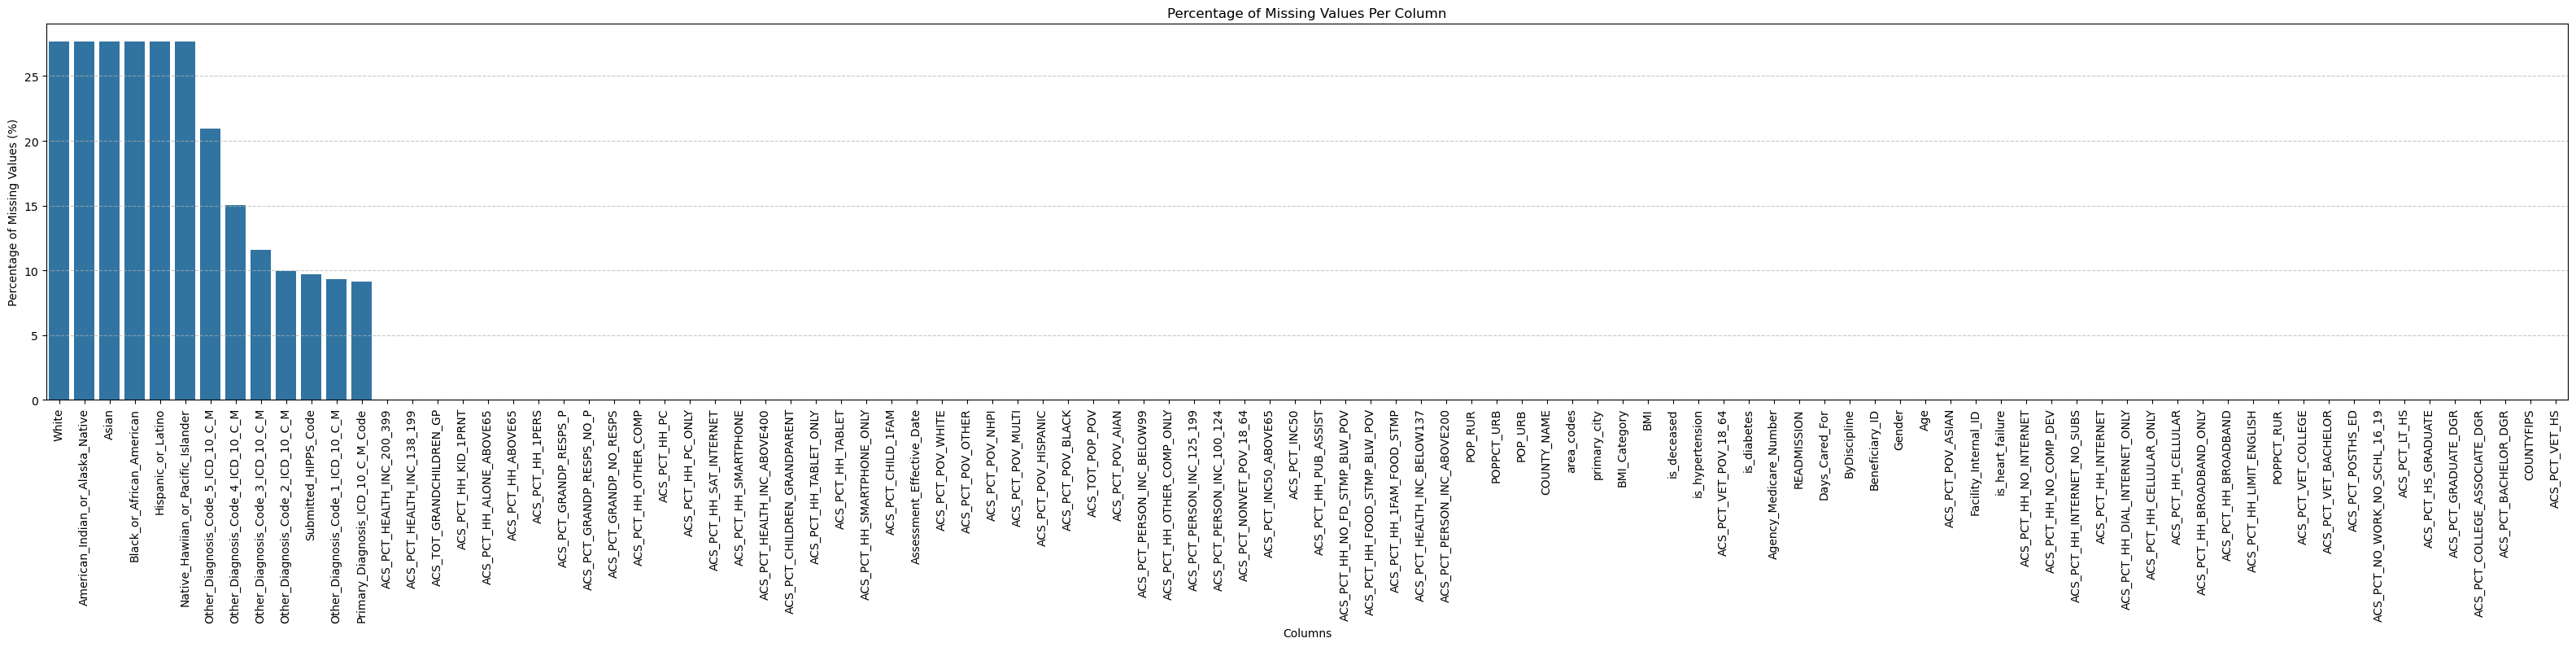

In [46]:
missing_percentage = (df_merged.isna().sum() / len(df_merged)) * 100

# Convert to DataFrame and sort by missing percentage
missing_percentage = missing_percentage.sort_values(ascending=False).to_frame('Missing Percentage')

# Plotting the missing percentage
plt.figure(figsize=(40, 6))
sns.barplot(x=missing_percentage.index, y=missing_percentage['Missing Percentage'])
plt.xticks(rotation=90, fontsize=10)
plt.ylabel('Percentage of Missing Values (%)')
plt.xlabel('Columns')
plt.title('Percentage of Missing Values Per Column')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [47]:
spark.stop()